In [ ]:
import argparse

import datetime
import random

import sys
import os 
import numpy
import types
import pandas as pd

from neuromancer.modules.activations import activations
from neuromancer.system import Node, System
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer

from Datasets.get_dataset import *
from getters import find_latest, load_function_encoder, get_coefficients
from Callbacks import TensorboardCallback, ProgressBarCallback, ListCallback, EvalCallback
from Policies.Policy import Policy
from getters import get_policy
from Datasets.GlycolyticOscillatorDataset import glycolytic_oscillator_dynamics
from Integrator import rk4_step

In [2]:
args = types.SimpleNamespace(
    batch_size=32,
    num_envs=100,
    num_epochs=1,
    horizon=50, #####
    seed=0,
    device="cuda",
    log_dir="logs/policy",
    n_layers=4,
    n_hidden=256,
    fe_load_path="latest",
    dataset="GlycolyticOscillator",
    policy_type="adaptive"
)

# Set the random seed for reproducibility
random.seed(args.seed)
numpy.random.seed(args.seed)
torch.manual_seed(args.seed)

In [3]:
# Fetch a dataset
dataset, _ = get_function_encoder_dataset(args)
args.fe_load_path = "logs/function_encoder/GlycolyticOscillator/seed_0/2025-11-04_13-32-19" 
print(f"Using latest function encoder model from {args.fe_load_path}")
args.log_dir = "logs/policy/GlycolyticOscillator/adaptive/seed_0/2025-11-04_20-52-25"


# load a model, to be used as dynamics with no gradients.
model = load_function_encoder(
    load_path=args.fe_load_path,
    device=args.device,
)

Using latest function encoder model from logs/function_encoder/GlycolyticOscillator/seed_0/2025-11-04_13-32-19


In [4]:
# get a large set of coefficients from the training dataset
coefficients, hp = get_coefficients(dataset, args, model)

# Training dataset generation
train_data, dev_data = get_trajectory_dataset(args, coefficients)

# prepare to train
train_loader = torch.utils.data.DataLoader(train_data, batch_size=args.batch_size, collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=args.batch_size,  collate_fn=dev_data.collate_fn, shuffle=False)

In [5]:
# create the learned dynamics model
dt = torch.tensor([[dataset.dt]], device=args.device)
def model_wrapper(x, u, c):
    ret = (
            # Function encoder expects a leading batch dimension, and a separate dt for every point.
            model((x.unsqueeze(1), u.unsqueeze(1), dt.expand(x.shape[0], 1) * dataset.rk4_nsteps), coefficients=c)
            + x.unsqueeze(1)
    ).squeeze(1)
    return ret
model_node = Node(model_wrapper, ["x", "u", 'c'], ["x"], name="model")

# create the neural net control policy
policy = get_policy(args, dataset, coefficients, len(model.basis_functions.basis_functions),)

# create the closed loop system
cl_system = System([policy, model_node], nsteps=args.horizon)
objectives, constraints = train_data.get_constraints_objectives(args.device)
components = [cl_system]
loss = PenaltyLoss(objectives, constraints)
problem = Problem(components, loss)

In [6]:
# create the white box dynamics model
def wbmodel_wrapper(x, u, k1s, K1s):
    for _ in range(dataset.rk4_nsteps):
        x = (
                rk4_step(glycolytic_oscillator_dynamics, x, u, dt[0], k1s=k1s, K1s=K1s) 
                + x
        )
    return x
wbmodel_node = Node(wbmodel_wrapper, ["x", "u", 'k1s', 'K1s'], ["x"], name="wbmodel")

# create the neural net control policy
policy = get_policy(args, dataset, coefficients, len(model.basis_functions.basis_functions),)

# create the closed loop system
cl_system_wb = System([policy, wbmodel_node], nsteps=args.horizon)
objectives, constraints = train_data.get_constraints_objectives(args.device)
components = [cl_system_wb]
loss = PenaltyLoss(objectives, constraints)
problem_wb = Problem(components, loss)

In [7]:
# create callbacks
cb1 = TensorboardCallback(args.log_dir)
cb2 = ProgressBarCallback(len(train_loader) * args.num_epochs)
cb3 = EvalCallback(dataset, dev_data, model, cb1.summary_writer)
callback = ListCallback([cb1, cb2, cb3])


optimizer = torch.optim.AdamW(policy.parameters(), lr=1e-3)
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=args.num_epochs,
    train_metric='train_loss',
    warmup=50,
    device=args.device,
    callback=callback
)

if problem_wb is not None:
    wb_trainer = Trainer(
        problem_wb,
        train_loader,
        dev_loader,
        optimizer=optimizer,
        epochs=args.num_epochs,
        train_metric='train_loss',
        warmup=50,
        device=args.device,
        callback=callback
    )


# load the policy
trainer.model.load_state_dict(torch.load(os.path.join(args.log_dir, "policy.pth")))

if problem_wb is not None:
    wb_trainer.model.load_state_dict(torch.load(os.path.join(args.log_dir, "policy.pth")))


Training...:   0%|          | 0/100 [00:00<?, ?it/s]

Testing Closed Loop System...
Plotting trajectory for closed loop system with white box model...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

0 3.0021039994364105 [0.72860003 1.20790005 0.044      0.33500001 0.2881     2.15569997
 0.0708    ] 4.000000026995244
1 3.0182403820713892 [0.79385172 1.12944913 0.07794718 0.25122413 0.23060752 2.15510188
 0.07232038] 4.000000034430208
2 3.028268386270448 [0.85875504 1.05982292 0.10264734 0.20863932 0.20448577 2.17075962
 0.07302349] 4.000000033322102
3 3.037271350770098 [0.92341853 0.99667579 0.11968761 0.18640977 0.19098814 2.1970838
 0.07330608] 4.00000001751393
4 3.047228836872504 [0.9879223  0.93879339 0

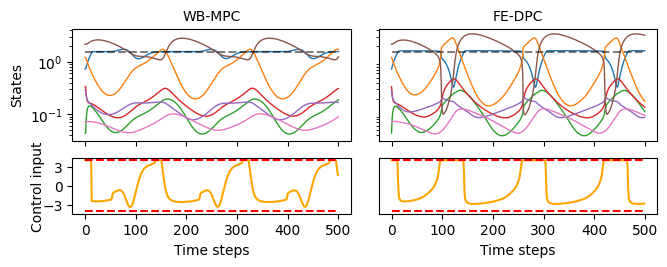

Function Encoder DPC computation time: 5.236448 s
White Box DPC computation time: 0.649571 s
Casadi MPC computation time: 148.807940 s


In [8]:
# plot the closed loop trajectories in the simulated system.
# fe_model = model, dt=torch.tensor([[dataset.dt]], device=args.device) * dataset.rk4_nsteps
with torch.no_grad():
    for i in range(1):
        R_fe_dpc, Y_fe_dpc, U_fe_dpc, Y_wb_dpc, U_wb_dpc, Y_wb_casadi, U_wb_casadi, hp_trajectory = train_data.plot_trajectory(coefficients, cl_system, args.log_dir, wb_cl_system=cl_system_wb, hp=hp, casadi_plot=True) 


In [9]:
def mse_loss(a, b):
    return torch.mean((a - b) ** 2).item()

# Convert numpy arrays to torch tensors for loss calculation
Y_wb_casadi_tensor = torch.from_numpy(Y_wb_casadi.T).to(R_fe_dpc.device)

loss_fe_dpc = mse_loss(R_fe_dpc, Y_fe_dpc)
loss_wb_dpc = mse_loss(R_fe_dpc, Y_wb_dpc)
loss_wb_casadi = mse_loss(R_fe_dpc, Y_wb_casadi_tensor)


loss_table = pd.DataFrame({
    "Reference": ["Reference vs Y_fe_dpc", "Reference vs Y_wb_dpc", "Reference vs Y_wb_casadi"],
    "MSE Loss": [loss_fe_dpc, loss_wb_dpc, loss_wb_casadi]
})

print(loss_table)

                  Reference  MSE Loss
0     Reference vs Y_fe_dpc  1.556024
1     Reference vs Y_wb_dpc  1.544269
2  Reference vs Y_wb_casadi  1.387698
